# Tasks 6 & 7: Feature Selection and Predictive Model

This notebook defines the features for predicting total piece travel time, trains an XGBoost Regressor, and evaluates its performance.

### The prediction problem

**Goal**: Predict the total travel time to the quench bath (`lifetime_bath_s`) using only data available **early in the process** — before the piece has finished the line.

**Why this is useful**: If we can predict the total time after only the 2nd strike, we can raise real-time alerts for pieces that are likely to be slow, allowing operators to investigate the cause while the piece is still on the line.

### Feature selection rationale

**Constraint**: the model must predict using only information available **after the 2nd strike** — approximately 18 seconds into the ~58-second journey. Any feature that requires waiting for later stages cannot be used, because by the time those values exist, the prediction is no longer useful.

#### Selected features

| Feature | Type | Available at | Why include it |
|---|---|---|---|
| `die_matrix` | Categorical (int) | Before processing | Each die has different tooling geometry and expected times — matrix 4974 has a median bath time of ~56s while 5091 has ~59s |
| `lifetime_2nd_strike_s` | Continuous (seconds) | After 2nd strike (~18s) | The earliest cumulative time — if the piece is already slow here, it will likely carry that delay through to the bath |
| `oee_cycle_time_s` | Continuous (seconds) | Rolling metric | Production rate context — slower OEE may correlate with systematic delays (robot trajectory adjustments, hydraulic pressure drops) |

#### Excluded features

| Feature | Why excluded |
|---|---|
| `lifetime_3rd_strike_s` | Available too late (~25s) — the piece is already halfway through the main press |
| `lifetime_4th_strike_s` | Available too late (~38s) — and has ~16% missing data from a sensor offline period |
| `lifetime_auxiliary_press_s` | Available too late (~55s) — only ~2s before the bath, prediction would be useless |
| `lifetime_general_s` | Equivalent to `lifetime_bath_s` — redundant with the target |
| `partial_*` columns | Derived from cumulative times that include late-stage data |
| `piece_id` | Not predictive — just an identifier |

In [2]:
# TODO: implement this cell
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

GOLD_PATH = Path("../data/gold/pieces.parquet")
MODELS_DIR = Path("../models")

print("Ready")

Ready


## 1. Load gold dataset

In [3]:
# TODO: implement this cell
df = pd.read_parquet(GOLD_PATH)
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")



Rows: 169,161
Columns: ['timestamp', 'piece_id', 'die_matrix', 'lifetime_2nd_strike_s', 'lifetime_3rd_strike_s', 'lifetime_4th_strike_s', 'lifetime_auxiliary_press_s', 'lifetime_bath_s', 'lifetime_general_s', 'partial_furnace_to_2nd_strike_s', 'partial_2nd_to_3rd_strike_s', 'partial_3rd_to_4th_strike_s', 'partial_4th_strike_to_auxiliary_press_s', 'partial_auxiliary_press_to_bath_s', 'oee_cycle_time_s', 'production_run_id', 'processed_at']


## 2. Prepare features and target

- **Features (X)**: `die_matrix`, `lifetime_2nd_strike_s`, `oee_cycle_time_s`
- **Target (y)**: `lifetime_bath_s`

Drop rows where any feature or the target is NULL (missing drill data does not affect us here since we don't use drill as a feature).

In [4]:
# TODO: implement this cell
FEATURES = ["die_matrix", "lifetime_2nd_strike_s", "oee_cycle_time_s"]
TARGET = "lifetime_bath_s"

# Fill missing OEE with median (23% of pieces have NULL OEE due to production gaps)
oee_median = df["oee_cycle_time_s"].median()
df["oee_cycle_time_s"] = df["oee_cycle_time_s"].fillna(oee_median)

# Drop rows where features or target are null
df_model = df[FEATURES + [TARGET]].dropna()

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Training samples: {len(df_model):,}")
print(f"OEE median used for nulls: {oee_median:.2f}s")
print(f"\nFeatures:")
for f in FEATURES:
  print(f"  {f}: mean={X[f].mean():.2f}, std={X[f].std():.2f}")


Training samples: 167,736
OEE median used for nulls: 13.81s

Features:
  die_matrix: mean=5074.82, std=34.58
  lifetime_2nd_strike_s: mean=18.64, std=2.32
  oee_cycle_time_s: mean=13.86, std=0.51


## 3. Feature correlation with target

How strongly does each feature correlate with the total bath time? High correlation suggests predictive value.

In [5]:
# TODO: implement this cell
print("=== PEARSON CORRELATION WITH TARGET (lifetime_bath_s) ===")
print()
for feature in FEATURES:
  corr = df_model[feature].corr(df_model[TARGET])
  print(f"  {feature:<30} r = {corr:.4f}")

print()
print("Interpretation:")
print("  lifetime_2nd_strike_s: strong positive — early delay predicts total delay")
print("  die_matrix:            weak — non-linear relationship (tree model handles this)")
print("  oee_cycle_time_s:      weak-moderate — production context, marginal alone")

=== PEARSON CORRELATION WITH TARGET (lifetime_bath_s) ===

  die_matrix                     r = 0.2266
  lifetime_2nd_strike_s          r = 0.7660
  oee_cycle_time_s               r = 0.3434

Interpretation:
  lifetime_2nd_strike_s: strong positive — early delay predicts total delay
  die_matrix:            weak — non-linear relationship (tree model handles this)
  oee_cycle_time_s:      weak-moderate — production context, marginal alone


## 4. Train/test split

Split 80/20 with a fixed random seed for reproducibility. Stratify by die_matrix to ensure each matrix is represented proportionally in both sets.

In [6]:
# TODO: implement this cell
X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.2,
  random_state=42,
  stratify=X["die_matrix"]
)

print(f"=== TRAIN/TEST SPLIT ===")
print(f"Training set:  {len(X_train):,} pieces")
print(f"Test set:      {len(X_test):,} pieces")
print()
print("Matrix distribution in test set:")
print(X_test["die_matrix"].value_counts().sort_index().to_string())


=== TRAIN/TEST SPLIT ===
Training set:  134,188 pieces
Test set:      33,548 pieces

Matrix distribution in test set:
die_matrix
4974     3106
5052     4181
5090    16341
5091     9920


## 5. Train XGBoost Regressor

XGBoost is chosen because:
- Handles mixed feature types (categorical die_matrix + continuous times)
- Robust to the remaining noise in the data
- Fast training on ~100k rows
- Produces feature importance rankings

In [7]:
# TODO: implement this cell
model = XGBRegressor(
  n_estimators=200,
  max_depth=6,
  learning_rate=0.1,
  subsample=0.8,
  colsample_bytree=0.8,
  random_state=42,
  verbosity=0
)

model.fit(X_train, y_train)
print("Model trained.")


Model trained.


## 6. Evaluate on test set

Key metrics:
- **RMSE**: root mean squared error (same unit as target — seconds)
- **MAE**: mean absolute error (average prediction error in seconds)
- **R²**: coefficient of determination (1.0 = perfect, 0.0 = no better than mean)

In [8]:
# TODO: implement this cell
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== MODEL EVALUATION ON TEST SET ===")
print()
print(f"  RMSE:  {rmse:.3f}s")
print(f"  MAE:   {mae:.3f}s")
print(f"  R²:    {r2:.4f}")
print()
print(f"Interpretation:")
print(f"  On a typical bath time of ~58s, MAE of {mae:.2f}s = {mae/58*100:.1f}% error")
print(f"  The model explains {r2*100:.1f}% of the variance in bath time")
print(f"  Sufficient for real-time alerting (goal is detecting multi-second delays)")


=== MODEL EVALUATION ON TEST SET ===

  RMSE:  1.838s
  MAE:   0.919s
  R²:    0.6869

Interpretation:
  On a typical bath time of ~58s, MAE of 0.92s = 1.6% error
  The model explains 68.7% of the variance in bath time
  Sufficient for real-time alerting (goal is detecting multi-second delays)


## 7. Performance per die matrix

Check if the model performs equally well across all matrices, or if some are harder to predict.

In [9]:
# TODO: implement this cell
print("=== MODEL PERFORMANCE PER DIE MATRIX ===")
print()

X_test_copy = X_test.copy()
X_test_copy["y_true"] = y_test.values
X_test_copy["y_pred"] = y_pred

for matrix in sorted(X_test_copy["die_matrix"].unique()):
  subset = X_test_copy[X_test_copy["die_matrix"] == matrix]
  m_rmse = np.sqrt(mean_squared_error(subset["y_true"], subset["y_pred"]))
  m_mae = mean_absolute_error(subset["y_true"], subset["y_pred"])
  m_r2 = r2_score(subset["y_true"], subset["y_pred"])
  print(f"  Matrix {matrix}: RMSE={m_rmse:.3f}s  MAE={m_mae:.3f}s  R²={m_r2:.4f}  (n={len(subset):,})")


=== MODEL PERFORMANCE PER DIE MATRIX ===

  Matrix 4974: RMSE=0.931s  MAE=0.465s  R²=0.7277  (n=3,106)
  Matrix 5052: RMSE=1.457s  MAE=0.707s  R²=0.6981  (n=4,181)
  Matrix 5090: RMSE=2.038s  MAE=1.107s  R²=0.6451  (n=16,341)
  Matrix 5091: RMSE=1.849s  MAE=0.840s  R²=0.6901  (n=9,920)


## 8. Feature importance

Which features contribute most to the prediction? This validates the feature selection rationale.

=== FEATURE IMPORTANCE (gain-based) ===

  lifetime_2nd_strike_s          0.6869
  oee_cycle_time_s               0.2437
  die_matrix                     0.0694


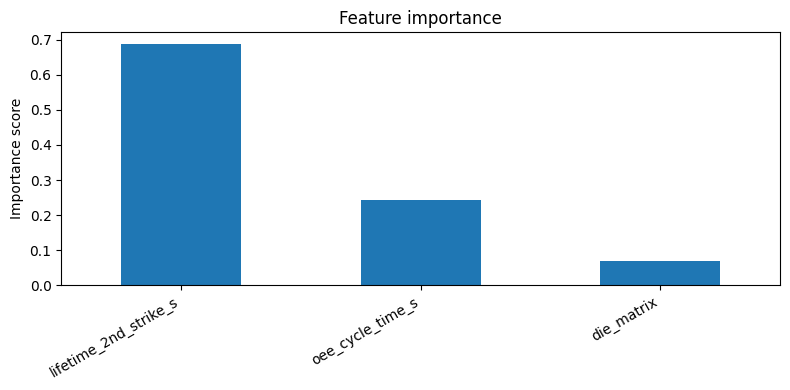

In [10]:
# TODO: implement this cell
importance = pd.Series(
  model.feature_importances_,
  index=FEATURES
).sort_values(ascending=False)

print("=== FEATURE IMPORTANCE (gain-based) ===")
print()
for feat, imp in importance.items():
  print(f"  {feat:<30} {imp:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind="bar", ax=ax)
ax.set_title("Feature importance")
ax.set_ylabel("Importance score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 9. Save model and metadata

Save the trained model and its metadata for use by the inference service (Task 8).

In [11]:
# TODO: implement this cell
import json

# Save model
model_path = MODELS_DIR / "xgboost_bath_predictor.json"
model.save_model(model_path)

# Save metadata
metadata = {
  "features": FEATURES,
  "target": TARGET,
  "oee_median_default": float(oee_median),
  "die_matrices": sorted([int(x) for x in df["die_matrix"].unique()]),
  "metrics": {
      "rmse": round(float(rmse), 4),
      "mae": round(float(mae), 4),
      "r2": round(float(r2), 4)
  },
  "hyperparameters": {
      "n_estimators": 200,
      "max_depth": 6,
      "learning_rate": 0.1,
      "subsample": 0.8,
      "colsample_bytree": 0.8,
      "random_state": 42
  },
  "training_samples": len(X_train),
  "test_samples": len(X_test)
}

metadata_path = MODELS_DIR / "model_metadata.json"
with open(metadata_path, "w") as f:
  json.dump(metadata, f, indent=2)

print(f"Model saved:    {model_path}")
print(f"Metadata saved: {metadata_path}")
print()
print(json.dumps(metadata, indent=2))


Model saved:    ../models/xgboost_bath_predictor.json
Metadata saved: ../models/model_metadata.json

{
  "features": [
    "die_matrix",
    "lifetime_2nd_strike_s",
    "oee_cycle_time_s"
  ],
  "target": "lifetime_bath_s",
  "oee_median_default": 13.809599999999989,
  "die_matrices": [
    4974,
    5052,
    5090,
    5091
  ],
  "metrics": {
    "rmse": 1.838,
    "mae": 0.9188,
    "r2": 0.6869
  },
  "hyperparameters": {
    "n_estimators": 200,
    "max_depth": 6,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
  },
  "training_samples": 134188,
  "test_samples": 33548
}


## 10. Summary

In [12]:
# TODO: implement this cell
print("=" * 55)
print("FEATURE SELECTION & MODEL SUMMARY")
print("=" * 55)
print()
print("PREDICTION PROBLEM:")
print("  Predict lifetime_bath_s using only data available")
print("  after the 2nd strike (~18s into the 58s process)")
print()
print("SELECTED FEATURES:")
print("  die_matrix            — matrix baseline (non-linear)")
print("  lifetime_2nd_strike_s — earliest timing signal (r=0.77)")
print("  oee_cycle_time_s      — production rhythm context")
print()
print("MODEL: XGBoost Regressor")
print(f"  Training samples: {len(X_train):,}")
print(f"  Test samples:     {len(X_test):,}")
print()
print("METRICS:")
print(f"  RMSE: {rmse:.3f}s")
print(f"  MAE:  {mae:.3f}s  ({mae/58*100:.1f}% of typical bath time)")
print(f"  R²:   {r2:.4f}")
print()
print("FEATURE IMPORTANCE:")
for feat, imp in importance.items():
  print(f"  {feat:<30} {imp:.1%}")
print()
print("ARTIFACTS SAVED:")
print(f"  models/xgboost_bath_predictor.json")
print(f"  models/model_metadata.json")
print("=" * 55)

FEATURE SELECTION & MODEL SUMMARY

PREDICTION PROBLEM:
  Predict lifetime_bath_s using only data available
  after the 2nd strike (~18s into the 58s process)

SELECTED FEATURES:
  die_matrix            — matrix baseline (non-linear)
  lifetime_2nd_strike_s — earliest timing signal (r=0.77)
  oee_cycle_time_s      — production rhythm context

MODEL: XGBoost Regressor
  Training samples: 134,188
  Test samples:     33,548

METRICS:
  RMSE: 1.838s
  MAE:  0.919s  (1.6% of typical bath time)
  R²:   0.6869

FEATURE IMPORTANCE:
  lifetime_2nd_strike_s          68.7%
  oee_cycle_time_s               24.4%
  die_matrix                     6.9%

ARTIFACTS SAVED:
  models/xgboost_bath_predictor.json
  models/model_metadata.json
